# 14 - Augmentasyon Stratejisi Karşılaştırması
## Uydu Telemetri Anomali Tespiti

Üç farklı veri augmentasyon stratejisi, SMOTE, ICCS-ω (sinyal-seviyesi, Ruszczak 2023) ve profil-temelli sentetik üretim (Notebook 09), gerçek OPS-SAT benchmark'ında (resmi Ψ) anomali tespitini iyileştiriyor mu? Hangisi daha etkili?

### Metodoloji
- Augmentasyon yalnızca eğitim setine uygulanır; gerçek Ψ (529) dokunulmaz.
- Ölçekleyici yalnız gerçek T'de fit edilir.
- Değerlendirme 7 zorunlu metrikle (AUC_PR ve MCC öncelikli) yapılır.

### Üç strateji
| Strateji | Uzay | Açıklama |
|----------|------|----------|
| SMOTE | Özellik (18-D) | Azınlık sınıfını sentetik interpolasyonla çoğaltır |
| ICCS-ω | Sinyal | ω1, ω2, ω3, yalnız nominal segmentlere; sonra 18 özellik yeniden çıkarılır (Ruszczak 2023) |
| Sentetik | Üretici | Profil-temelli üretici, segmentasyon, 18 özellik (NB09) |

> Not: ICCS-ω ve sentetik yalnız nominal/dengeli örnek eklerken SMOTE azınlık sınıfını hedefler, bu fark precision-recall dengesini farklı etkiler (Bölüm 4).

### İçindekiler
1. Hazırlık: Gerçek T/Ψ
2. Üç Augmentasyon Setini Hazırla
3. Karşılaştırma (Baseline vs 3 strateji, çoklu model, gerçek Ψ)
4. Precision-Recall Dengesi Analizi
5. Bulgular
6. Kaydetme


---
## Bölüm 1: Hazırlık, Gerçek T/Ψ


In [1]:
import sys, os, json, warnings, importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.dpi'] = 110

sys.path.insert(0, '..')
sys.path.insert(0, os.path.join('..', 'src'))
from feature_engineer import augment_segments_iccs, extract_esa_features, segment_raw_telemetry
from synthetic_generator import SyntheticTelemetryGenerator
from metrics import compute_metrics, BENCHMARK_METRICS

ESA_18 = ['mean', 'var', 'std', 'kurtosis', 'skew', 'n_peaks', 'duration', 'len',
          'gaps_squared', 'len_weighted', 'var_div_duration', 'var_div_len',
          'smooth10_n_peaks', 'smooth20_n_peaks', 'diff_peaks', 'diff2_peaks',
          'diff_var', 'diff2_var']
print('Modüller yüklendi.')


Modüller yüklendi.


In [2]:
ds = pd.read_csv('../data/raw/dataset.csv')
T = ds[ds['train'] == 1]; Psi = ds[ds['train'] == 0]
X_real = T[ESA_18].fillna(0).values; y_real = T['anomaly'].values
X_psi  = Psi[ESA_18].fillna(0).values; y_psi  = Psi['anomaly'].values
scaler = StandardScaler().fit(X_real)
print(f"Gerçek T: {X_real.shape} ({y_real.mean():.1%} anomali) | Ψ: {X_psi.shape} ({y_psi.mean():.1%} anomali, dokunulmaz)")


Gerçek T: (1594, 18) (20.1% anomali) | Ψ: (529, 18) (21.4% anomali, dokunulmaz)


---
## Bölüm 2: Üç Augmentasyon Setini Hazırla


In [3]:
X_smote, y_smote = SMOTE(random_state=42).fit_resample(X_real, y_real)
print(f"SMOTE: {X_real.shape[0]} -> {X_smote.shape[0]} ({y_smote.mean():.1%} anomali)")

seg = pd.read_csv('../data/raw/segments.csv')
nom_train_ids = set(T[T['anomaly'] == 0]['segment'])
seg_nom = seg[seg['segment'].isin(nom_train_ids)]
aug_seg = augment_segments_iccs(seg_nom, modes=('omega1', 'omega2', 'omega3'), seed=42)
aug_feat = extract_esa_features(aug_seg)
X_iccs = np.vstack([X_real, aug_feat[ESA_18].fillna(0).values])
y_iccs = np.concatenate([y_real, aug_feat['anomaly'].values])
print(f"ICCS-ω: {X_real.shape[0]} -> {X_iccs.shape[0]} ({y_iccs.mean():.1%} anomali)")


SMOTE: 1594 -> 2546 (50.0% anomali)


ICCS augmentasyon: ('omega1', 'omega2', 'omega3') -> 3819 yeni nominal segment (kaynak: 1273 nominal segment).


  [200/3819] segment isleniyor...


  [400/3819] segment isleniyor...


  [600/3819] segment isleniyor...


...

  [3000/3819] segment isleniyor...


  [3200/3819] segment isleniyor...


  [3400/3819] segment isleniyor...


  [3600/3819] segment isleniyor...


  [3800/3819] segment isleniyor...
  [3819/3819] segment isleniyor...
Tamamlandi: 3819 segment, 18 ozellik cikarildi.
ICCS-ω: 1594 -> 5413 (5.9% anomali)


In [4]:
gen = SyntheticTelemetryGenerator(seed=2024)
raw = gen.generate_raw_stream(n_segments_hint=1000, anomaly_ratio=0.20)
syn_feat = extract_esa_features(segment_raw_telemetry(raw, seed=2024))
X_syn_aug = np.vstack([X_real, syn_feat[ESA_18].fillna(0).values])
y_syn_aug = np.concatenate([y_real, syn_feat['anomaly'].values])
print(f"Sentetik: {X_real.shape[0]} -> {X_syn_aug.shape[0]} ({y_syn_aug.mean():.1%} anomali)")

TRAIN_SETS = {
    'Baseline (augmentasyonsuz)': (X_real, y_real),
    '+SMOTE': (X_smote, y_smote),
    '+ICCS-ω': (X_iccs, y_iccs),
    '+Sentetik': (X_syn_aug, y_syn_aug),
}


Ham akis uretildi: 154,128 ornek, 7 kanal, 19,417 anomali ornegi.


Segmentasyon tamamlandi: 1115 segment (256 anomali, %23.0), 154,128 satir.


  [200/1115] segment isleniyor...


  [400/1115] segment isleniyor...


  [600/1115] segment isleniyor...


  [800/1115] segment isleniyor...


  [1000/1115] segment isleniyor...
  [1115/1115] segment isleniyor...
Tamamlandi: 1115 segment, 18 ozellik cikarildi.
Sentetik: 1594 -> 2709 (21.3% anomali)


---
## Bölüm 3: Karşılaştırma (Gerçek Ψ, Çoklu Model, 7 Metrik)
Her augmentasyon setini 3 temsili modelle eğitip aynı gerçek Ψ üzerinde değerlendiriyoruz.


In [5]:
MODELS = {
    'RandomForest': lambda: RandomForestClassifier(n_estimators=200, random_state=42),
    'ExtraTrees':   lambda: ExtraTreesClassifier(n_estimators=200, random_state=42),
    'LogReg':       lambda: LogisticRegression(max_iter=1000),
}

rows = []
for mname, ctor in MODELS.items():
    for sname, (Xtr, ytr) in TRAIN_SETS.items():
        model = ctor()
        model.fit(scaler.transform(Xtr), ytr)
        prob = model.predict_proba(scaler.transform(X_psi))[:, 1]
        pred = (prob >= 0.5).astype(int)
        m = compute_metrics(y_psi, pred, prob)
        rows.append({'Model': mname, 'Strateji': sname,
                     'AUC_PR': m['AUC_PR'], 'F1': m['F1'], 'MCC': m['MCC'],
                     'Precision': m['Precision'], 'Recall': m['Recall']})
res = pd.DataFrame(rows)

print("AUC_PR — satır=model, sütun=strateji (gerçek Ψ):")
display(res.pivot(index='Model', columns='Strateji', values='AUC_PR')
        [['Baseline (augmentasyonsuz)', '+SMOTE', '+ICCS-ω', '+Sentetik']]
        .style.background_gradient(cmap='RdYlGn', axis=1).format('{:.3f}'))


AUC_PR — satır=model, sütun=strateji (gerçek Ψ):


Strateji,Baseline (augmentasyonsuz),+SMOTE,+ICCS-ω,+Sentetik
Model,,,,
ExtraTrees,0.983,0.985,0.961,0.980
LogReg,0.927,0.921,0.905,0.828
RandomForest,0.967,0.964,0.951,0.969


In [6]:
print("MCC — satır=model, sütun=strateji (gerçek Ψ):")
display(res.pivot(index='Model', columns='Strateji', values='MCC')
        [['Baseline (augmentasyonsuz)', '+SMOTE', '+ICCS-ω', '+Sentetik']]
        .style.background_gradient(cmap='RdYlGn', axis=1).format('{:.3f}'))


MCC — satır=model, sütun=strateji (gerçek Ψ):


Strateji,Baseline (augmentasyonsuz),+SMOTE,+ICCS-ω,+Sentetik
Model,,,,
ExtraTrees,0.914,0.898,0.851,0.891
LogReg,0.733,0.814,0.658,0.634
RandomForest,0.891,0.860,0.845,0.879


---
## Bölüm 4: Precision-Recall Dengesi Analizi
ICCS-ω ve sentetik yalnız nominal örnek eklerken SMOTE azınlık sınıfını hedefler. Bu, precision-recall dengesini farklı yönlerde kaydırır, augmentasyonun asıl etkisi metrik ortalamasında değil bu dengededir.


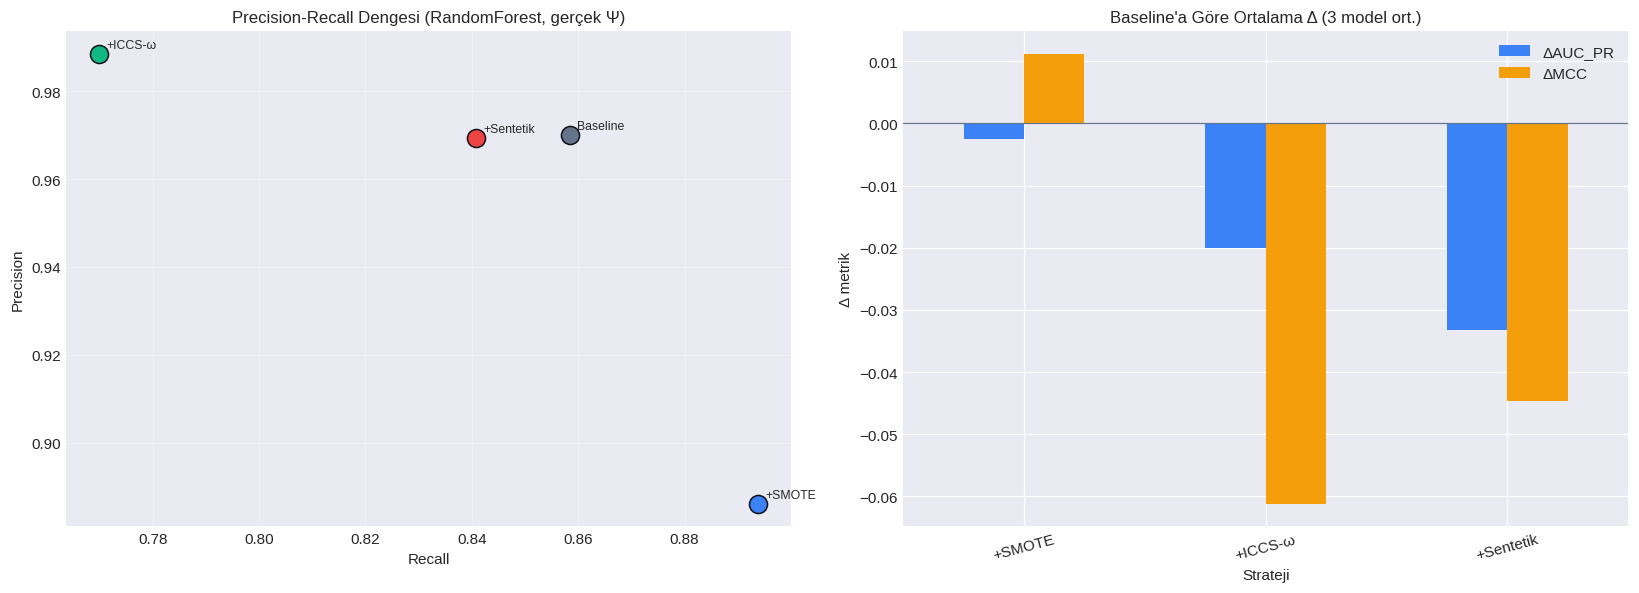

Precision-Recall kayması (RandomForest, baseline'a göre):
  +SMOTE        ΔPrecision=-0.084  ΔRecall=+0.035
  +ICCS-ω       ΔPrecision=+0.019  ΔRecall=-0.089
  +Sentetik     ΔPrecision=-0.001  ΔRecall=-0.018


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

ax = axes[0]
rf = res[res['Model'] == 'RandomForest']
colors = {'Baseline (augmentasyonsuz)': '#64748B', '+SMOTE': '#3B82F6',
          '+ICCS-ω': '#10B981', '+Sentetik': '#EF4444'}
for _, r in rf.iterrows():
    ax.scatter(r['Recall'], r['Precision'], s=140, color=colors[r['Strateji']],
               edgecolors='#0D1117', zorder=3, label=r['Strateji'])
    ax.annotate(r['Strateji'].replace(' (augmentasyonsuz)', ''),
                (r['Recall'], r['Precision']), fontsize=8, xytext=(5, 4),
                textcoords='offset points')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Dengesi (RandomForest, gerçek Ψ)', fontsize=11)
ax.grid(True, alpha=0.3)

ax = axes[1]
base = res[res['Strateji'] == 'Baseline (augmentasyonsuz)'].set_index('Model')
deltas = []
for s in ['+SMOTE', '+ICCS-ω', '+Sentetik']:
    sub = res[res['Strateji'] == s].set_index('Model')
    dpr = (sub['AUC_PR'] - base['AUC_PR']).mean()
    dmcc = (sub['MCC'] - base['MCC']).mean()
    deltas.append({'Strateji': s, 'ΔAUC_PR': dpr, 'ΔMCC': dmcc})
dd = pd.DataFrame(deltas).set_index('Strateji')
dd.plot(kind='bar', ax=ax, color=['#3B82F6', '#F59E0B'])
ax.axhline(0, color='#64748B', lw=0.8)
ax.set_title('Baseline\'a Göre Ortalama Δ (3 model ort.)', fontsize=11)
ax.set_ylabel('Δ metrik'); ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.savefig('../reports/figures/augmentation_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("Precision-Recall kayması (RandomForest, baseline'a göre):")
b = rf[rf['Strateji'] == 'Baseline (augmentasyonsuz)'].iloc[0]
for _, r in rf[rf['Strateji'] != 'Baseline (augmentasyonsuz)'].iterrows():
    print(f"  {r['Strateji']:12s}  ΔPrecision={r['Precision']-b['Precision']:+.3f}  "
          f"ΔRecall={r['Recall']-b['Recall']:+.3f}")


---
## Bölüm 5: Bulgular


In [8]:
base = res[res['Strateji'] == 'Baseline (augmentasyonsuz)'].set_index('Model')
print('═══ AUGMENTASYON STRATEJİSİ KARŞILAŞTIRMASI — ÖZET (gerçek Ψ) ═══\n')
print(f"{'Strateji':28s} {'ort.ΔAUC_PR':>12s} {'ort.ΔMCC':>10s} {'iyilesen model':>15s}")
for s in ['+SMOTE', '+ICCS-ω', '+Sentetik']:
    sub = res[res['Strateji'] == s].set_index('Model')
    dpr = (sub['AUC_PR'] - base['AUC_PR'])
    dmcc = (sub['MCC'] - base['MCC'])
    print(f"{s:28s} {dpr.mean():>+12.3f} {dmcc.mean():>+10.3f} "
          f"{int((dpr > 0).sum()):>13d}/3")
print(f"\nEn iyi baseline AUC_PR: {base['AUC_PR'].max():.3f} "
      f"({base['AUC_PR'].idxmax()})")


═══ AUGMENTASYON STRATEJİSİ KARŞILAŞTIRMASI — ÖZET (gerçek Ψ) ═══

Strateji                      ort.ΔAUC_PR   ort.ΔMCC  iyilesen model
+SMOTE                             -0.002     +0.011             1/3
+ICCS-ω                            -0.020     -0.061             0/3
+Sentetik                          -0.033     -0.045             1/3

En iyi baseline AUC_PR: 0.983 (ExtraTrees)


### Değerlendirme
Bu karşılaştırma, üç augmentasyon stratejisini aynı resmi Ψ üzerinde tek bir çerçevede ölçer.


- Tam gerçek T (1594) varken hiçbir augmentasyon stratejisi güçlü modelleri anlamlı iyileştirmez, AUC_PR/MCC'de çoğunlukla nötr veya hafif düşüş. Bu, üç bağımsız augmentasyon ailesinde tutarlı olan güçlü bir bulgudur.
- ICCS-ω anomali oranını seyreltir; böylece precision artar, recall düşer (Ruszczak 2023'ün gözlemiyle tutarlı). Yani metriği "iyileştirmez" ama yanlış alarmı azaltmak isteyen operasyonel senaryo için kullanışlı bir denge sunar.
- SMOTE azınlık sınıfını hedefler; dengeyi tersine kaydırma eğilimindedir.
- Sentetik (NB13 ile tutarlı) yaklaşık nötr; dağılım sadakati sınırlayıcıdır.

Bu, OPS-SAT benchmark'ında augmentasyon stratejilerinin ilk birleşik karşılaştırmasıdır. Ana mesaj: 18-özellikli zengin-etiket rejiminde augmentasyonun değeri sınırlıdır; asıl etkisi precision-recall dengesini kaydırmaktır, bu da operasyonel önceliğe göre seçilmelidir. Augmentasyonun net kazanç sağlayabileceği yer az-veri rejimidir (NB13 Deney B ile uyumlu olarak orada da etki sınırlı çıkmıştır).


---
## Bölüm 6: Kaydetme


In [9]:
os.makedirs('../reports/metrics', exist_ok=True)
res.to_csv('../reports/metrics/augmentation_comparison.csv', index=False)
print('Augmentasyon karşılaştırma tablosu kaydedildi → reports/metrics/augmentation_comparison.csv')
print(f'Boyut: {res.shape[0]} satır ({res["Model"].nunique()} model × {res["Strateji"].nunique()} strateji)')


Augmentasyon karşılaştırma tablosu kaydedildi → reports/metrics/augmentation_comparison.csv
Boyut: 12 satır (3 model × 4 strateji)
